# Notebook 06: Advanced Diagnostics for Quantile Regression

## Learning Objectives

By the end of this notebook, you will be able to:

1. Apply QR-specific diagnostic tests (Khmaladze, He-Zhu)
2. Use a traffic light system for model health assessment
3. Identify quantile-specific outliers and influential observations
4. Interpret goodness-of-fit measures for QR
5. Generate comprehensive diagnostic reports
6. Take corrective actions based on diagnostic results

## Duration
90–120 minutes

## Prerequisites
- Notebooks 01–03 (fundamentals, quantile process, fixed effects)
- Basic hypothesis testing

## Level
Advanced

## References
- Khmaladze & Koul (2004). Martingale Transforms Goodness-of-Fit Tests
- He & Zhu (2003). A Lack-of-Fit Test for Quantile Regression
- Koenker & Machado (1999). Goodness of Fit for Quantile Regression

In [1]:
# Standard libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Statistical libraries
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess

# PanelBox imports
from panelbox import PooledOLS
from panelbox.diagnostics.quantile import (
    AdvancedDiagnostics,
    QuantileRegressionDiagnostics,
)
from panelbox.models.quantile import PooledQuantile

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Define paths (relative to notebooks/)
BASE_DIR = Path("..")
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"
REPORTS_DIR = OUTPUT_DIR / "reports"

# Create output directories
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Output directory: {OUTPUT_DIR}")

Setup complete!
Data directory: ../data
Output directory: ../outputs


---

## 1. Introduction & Motivation

### Key Question

> *"How do we know if our quantile regression model is correctly specified?"*

In OLS, we have a well-developed toolkit for diagnostics:
- $R^2$ and adjusted $R^2$
- F-test for joint significance
- Residual normality (Jarque-Bera, Shapiro-Wilk)
- Homoskedasticity (White, Breusch-Pagan)
- Specification (Ramsey RESET)

**Quantile Regression diagnostics** present different challenges:

| Aspect | OLS | Quantile Regression |
|--------|-----|--------------------|
| Goodness of fit | $R^2$ | Pseudo-$R^2$ (check loss based) |
| Residual distribution | Should be normal | NOT normal by design |
| Heteroskedasticity | Bad (violates assumptions) | Expected and interesting |
| Specification test | Ramsey RESET | Khmaladze test |
| Outlier detection | Standardized residuals | MAD-based residuals |
| Influence | Cook's distance | QR-adapted Cook's distance |

> **Key Insight**  
> QR diagnostics require **different tools** than OLS. Heteroskedasticity is not a problem—it's a feature that QR is designed to capture. The key concerns are correct **functional form** and **quantile-specific** outliers.

In [2]:
# Load Card education dataset
from panelbox.datasets import load_dataset

data = load_dataset("card_education", category="quantile")

print(f"Dataset shape: {data.shape}")
print(f"Variables: {data.columns.tolist()}")
print(f"N observations: {len(data)}")
print(f"N individuals: {data['id'].nunique()}")
print(f"N periods: {data['year'].nunique()}")
print()
display(data.head())


Dataset shape: (3000, 12)
Variables: ['id', 'year', 'lwage', 'educ', 'exper', 'black', 'south', 'married', 'female', 'union', 'hours', 'age']
N observations: 3000
N individuals: 500
N periods: 6



,id,year,lwage,educ,exper,black,south,married,female,union,hours,age
0,1,1,4.2353,13.2,19.6,1,0,0,1,0,38.5,39.7
1,1,2,2.5440,13.2,23.5,1,0,0,1,1,40.8,40.7
2,1,3,4.2175,13.2,20.8,1,0,1,1,0,31.8,41.7
3,1,4,3.0313,13.2,23.6,1,0,1,1,1,41.8,42.7
4,1,5,2.0460,13.2,26.5,1,0,0,1,0,26.2,43.7


In [3]:
# Prepare arrays for quantile regression
# Model: lwage = b0 + b1*educ + b2*exper + b3*exper^2 + u

y = data["lwage"].values
var_names = ["const", "educ", "exper", "exper_sq"]

X = np.column_stack(
    [np.ones(len(data)), data["educ"].values, data["exper"].values, data["exper"].values ** 2]
)
entity_id = data["id"].values

print(f"Dependent variable (y): {y.shape}")
print(f"Design matrix (X): {X.shape}")
print(f"Variables: {var_names}")

Dependent variable (y): (3000,)
Design matrix (X): (3000, 4)
Variables: ['const', 'educ', 'exper', 'exper_sq']


In [4]:
# Fit baseline models
# OLS for comparison
ols_model = PooledOLS("lwage ~ educ + exper + I(exper**2)", data, entity_col="id", time_col="year")
ols_result = ols_model.fit(cov_type="clustered")

# Median regression (tau = 0.5)
qr_model_50 = PooledQuantile(y, X, entity_id=entity_id, quantiles=0.5)
qr_result_50 = qr_model_50.fit(se_type="cluster")

# Multiple quantiles
tau_list = [0.1, 0.25, 0.5, 0.75, 0.9]
qr_results = {}
for tau in tau_list:
    model = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau)
    qr_results[tau] = model.fit(se_type="cluster")

print("Baseline models fitted:")
print(f"  OLS: R-squared = {ols_result.rsquared:.4f}")
print(f"  QR (tau=0.5): converged = {qr_result_50.converged}")
print(f"  QR multiple: {len(qr_results)} quantiles estimated")

Baseline models fitted:
  OLS: R-squared = 0.0096
  QR (tau=0.5): converged = True
  QR multiple: 5 quantiles estimated


---

## 2. Diagnostic Tests

### 2.1 Goodness of Fit: Pseudo-$R^2$

The **Koenker-Machado Pseudo-$R^2$** compares the check loss of the full model to an intercept-only model:

$$\text{Pseudo-}R^2(\tau) = 1 - \frac{\sum_{i=1}^n \rho_\tau(y_i - X_i'\hat{\beta}(\tau))}{\sum_{i=1}^n \rho_\tau(y_i - \hat{Q}_\tau(y))}$$

**Interpretation:**
- Range: $[0, 1]$ (can be negative in theory)
- Higher is better
- Typically much lower than OLS $R^2$
- **NOT** comparable to OLS $R^2$—uses different loss functions

### Sparsity

The **sparsity** parameter $s(\tau) = 1/f(Q_\tau)$ measures the density of observations near the estimated quantile:
- Low density (high sparsity) at tails → less reliable inference
- Used internally to compute standard errors

In [5]:
# Basic diagnostics using QuantileRegressionDiagnostics
basic_diag = QuantileRegressionDiagnostics(
    model=qr_model_50, params=qr_result_50.params.ravel(), tau=0.5
)

# Pseudo-R-squared
pr2 = basic_diag.pseudo_r2()
print(f"Pseudo-R-squared (tau=0.5): {pr2:.4f}")

# Full goodness-of-fit summary
gof = basic_diag.goodness_of_fit()
print("\nGoodness-of-Fit Statistics:")
for key, val in gof.items():
    print(f"  {key:<20}: {val:.4f}")

# Symmetry test
sym_stat, sym_pval = basic_diag.symmetry_test()
print("\nSymmetry Test:")
print(f"  Statistic: {sym_stat:.4f}")
print(f"  P-value: {sym_pval:.4f}")
print(f"  Result: {'PASS' if sym_pval > 0.05 else 'FAIL'}")

Pseudo-R-squared (tau=0.5): 0.0115

Goodness-of-Fit Statistics:
  pseudo_r2           : 0.0115
  mean_residual       : 0.0015
  median_residual     : -0.0000
  quantile_count      : 0.1320
  sparsity            : 0.3482

Symmetry Test:
  Statistic: 0.0365
  P-value: 0.9709
  Result: PASS


In [6]:
# Compare Pseudo-R-squared across quantiles
def check_loss(u, tau):
    """Compute check (pinball) loss."""
    return np.sum(u * (tau - (u < 0).astype(float)))


def pseudo_r_squared(y, X, params, tau):
    """Koenker-Machado Pseudo-R-squared."""
    resid_full = y - X @ params
    loss_full = check_loss(resid_full, tau)
    q_tau = np.quantile(y, tau)
    resid_restricted = y - q_tau
    loss_restricted = check_loss(resid_restricted, tau)
    return 1 - loss_full / loss_restricted if loss_restricted != 0 else 0


print("Pseudo-R-squared across quantiles:")
print(f"{'Quantile':<12} {'Pseudo-R2':<12} {'Check Loss (model)':<20} {'Check Loss (null)':<18}")
print("-" * 62)

for tau in tau_list:
    params = qr_results[tau].params.ravel()
    pr2 = pseudo_r_squared(y, X, params, tau)
    resid = y - X @ params
    loss_model = check_loss(resid, tau)
    loss_null = check_loss(y - np.quantile(y, tau), tau)
    print(f"{tau:<12.2f} {pr2:<12.4f} {loss_model:<20.2f} {loss_null:<18.2f}")

Pseudo-R-squared across quantiles:
Quantile     Pseudo-R2    Check Loss (model)   Check Loss (null) 
--------------------------------------------------------------
0.10         0.0068       976.86               983.57            
0.25         0.0025       1609.30              1613.32           
0.50         0.0115       1905.29              1927.37           
0.75         0.0216       1615.76              1651.36           
0.90         0.0185       1014.77              1033.85           


In [7]:
# Full diagnostic summary for median regression
# Note: summary() calls goodness_of_fit_test() which needs model.n_params
# Workaround: set n_params on the model object before calling summary()
qr_model_50.n_params = X.shape[1]
print(basic_diag.summary())


Quantile Regression Diagnostics (τ=0.5)

Pseudo R²:                0.0115
Sparsity estimate:       0.3482
Quantile count:          0.1320

Residual Statistics:
------------------------------------------------------------
Mean:                    0.0015
Median:                  -0.0000
Std Dev:                 1.8145

Specification Tests:
------------------------------------------------------------
Symmetry Test:           0.0365 (p=0.9709)
Goodness of Fit Test:    1.1074 (p=0.9534)



### 2.2 Khmaladze Specification Test

The **Khmaladze test** (Khmaladze & Koul, 2004) tests whether the conditional quantile model is correctly specified:

$$H_0: Q_\tau(Y|X) = X'\beta(\tau) \text{ is correct}$$
$$H_1: \text{Misspecification (omitted variables, wrong functional form)}$$

**How it works:**
1. Compute residuals from the fitted model
2. Construct a Khmaladze-transformed empirical process
3. Compute a Kolmogorov-Smirnov type supremum statistic
4. Test against the Brownian bridge distribution

If we **reject** $H_0$, the model is misspecified—we may need to add variables, interactions, or nonlinear terms.

In [8]:
# Build a QuantilePanelResult-like wrapper for AdvancedDiagnostics
# AdvancedDiagnostics expects result.results[tau] with .params and result.model with .X, .y


class SimpleResult:
    """Wrapper to adapt PooledQuantileResults for AdvancedDiagnostics."""

    def __init__(self, params, converged=True):
        self.params = params
        self.converged = converged


class SimpleModel:
    """Wrapper to hold X and y for diagnostics."""

    def __init__(self, X, y):
        self.X = X
        self.y = y


class ResultWrapper:
    """Wraps PooledQuantileResults into format expected by AdvancedDiagnostics."""

    def __init__(self, qr_results_dict, X, y):
        self.results = {}
        for tau, res in qr_results_dict.items():
            self.results[tau] = SimpleResult(params=res.params.ravel(), converged=res.converged)
        self.model = SimpleModel(X, y)


# Create wrapper with all quantile results
result_wrapped = ResultWrapper(qr_results, X, y)

print(
    f"Wrapped result with {len(result_wrapped.results)} quantiles: {sorted(result_wrapped.results.keys())}"
)
print(f"X shape: {result_wrapped.model.X.shape}")
print(f"y shape: {result_wrapped.model.y.shape}")

Wrapped result with 5 quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]
X shape: (3000, 4)
y shape: (3000,)


In [9]:
# Run Khmaladze specification test
diag = AdvancedDiagnostics(result_wrapped, verbose=False)
diag.test_specification(tau=0.5)

khm = diag.diagnostics[-1]
print("KHMALADZE SPECIFICATION TEST")
print("=" * 50)
print("H0: Model Q_tau(Y|X) = X'beta(tau) is correct")
print("H1: Misspecification")
print("")
print(f"Statistic (KS): {khm.statistic:.4f}")
print(f"P-value:        {khm.p_value:.4f}")
print(f"Status:         {khm.status.upper()}")
print(f"Message:        {khm.message}")
if khm.recommendation:
    print(f"Recommendation: {khm.recommendation}")

KHMALADZE SPECIFICATION TEST
H0: Model Q_tau(Y|X) = X'beta(tau) is correct
H1: Misspecification

Statistic (KS): 13.7022
P-value:        0.0000
Status:         FAIL
Message:        Strong evidence of misspecification
Recommendation: Model is misspecified. Add omitted variables or transform existing ones


### 2.3 He-Zhu Heteroskedasticity Test

The **He-Zhu test** (He & Zhu, 2003) tests whether the conditional variance depends on covariates:

$$H_0: \text{Homoskedasticity (constant variance)}$$
$$H_1: \text{Heteroskedasticity (variance depends on } X\text{)}$$

**How it works:**
1. Compute residuals from the QR model
2. Regress $|\hat{u}|$ on $X$ (auxiliary regression)
3. Compute LM statistic: $n \times R^2_{\text{aux}}$
4. Compare to $\chi^2_{k-1}$ distribution

If we **reject** $H_0$, heteroskedasticity is present—consider using a **location-scale model** (Notebook 05).

In [10]:
# Run He-Zhu heteroskedasticity test
diag_hz = AdvancedDiagnostics(result_wrapped, verbose=False)
diag_hz.test_heteroscedasticity(tau=0.5)

hz = diag_hz.diagnostics[-1]
print("HE-ZHU HETEROSKEDASTICITY TEST")
print("=" * 50)
print("H0: Homoskedasticity (constant variance)")
print("H1: Heteroskedasticity (variance depends on X)")
print("")
print(f"LM Statistic: {hz.statistic:.4f}")
print(f"P-value:      {hz.p_value:.4f}")
print(f"Status:       {hz.status.upper()}")
print(f"Message:      {hz.message}")
if hz.recommendation:
    print(f"Recommendation: {hz.recommendation}")

if hz.details:
    print("\nDetails:")
    print(f"  R-squared (auxiliary): {hz.details.get('r2_auxiliary', 'N/A'):.4f}")
    print(f"  Degrees of freedom:   {hz.details.get('df', 'N/A')}")

HE-ZHU HETEROSKEDASTICITY TEST
H0: Homoskedasticity (constant variance)
H1: Heteroskedasticity (variance depends on X)

LM Statistic: 68.1201
P-value:      0.0000
Status:       FAIL
Message:      Strong evidence of heteroscedasticity
Recommendation: Use location-scale model or weighted QR

Details:
  R-squared (auxiliary): 0.0227
  Degrees of freedom:   3


### 2.4 Outlier Detection

In quantile regression, outliers are **quantile-specific**: an observation unusual at $\tau=0.1$ may not be unusual at $\tau=0.9$.

We use **MAD-based detection** (Median Absolute Deviation), which is more robust than standard deviation:

$$\text{MAD} = \text{median}(|u_i - \text{median}(u)|)$$

$$\text{Standardized residual} = \frac{u_i}{1.4826 \times \text{MAD}}$$

An observation is flagged as an outlier if $|\text{std. resid}| > 3$.

The constant $1.4826$ makes MAD consistent with standard deviation under normality.

In [11]:
# Outlier detection
diag_out = AdvancedDiagnostics(result_wrapped, verbose=False)
diag_out.test_outliers(tau=0.5, threshold=3.0)

out = diag_out.diagnostics[-1]
print("OUTLIER DETECTION (MAD-based)")
print("=" * 50)
print("Threshold:    3.0 MAD units")
print(f"N outliers:   {int(out.statistic)}")
print(f"Percentage:   {out.p_value * 100:.2f}%")
print(f"Status:       {out.status.upper()}")
print(f"Message:      {out.message}")
if out.recommendation:
    print(f"Recommendation: {out.recommendation}")

# Show outlier details
if hasattr(diag_out, "outlier_indices") and len(diag_out.outlier_indices) > 0:
    print(f"\nOutlier indices (first 20): {diag_out.outlier_indices[:20].tolist()}")
    print(f"Outlier residuals (first 10): {diag_out.outlier_residuals[:10].round(2).tolist()}")

OUTLIER DETECTION (MAD-based)
Threshold:    3.0 MAD units
N outliers:   187
Percentage:   6.23%
Status:       FAIL
Message:      187 outliers detected (6.2%)
Recommendation: Too many outliers. Check data quality or use robust methods

Outlier indices (first 20): [15, 45, 126, 144, 164, 166, 179, 180, 216, 238, 241, 248, 300, 313, 327, 328, 331, 359, 364, 387]
Outlier residuals (first 10): [-3.78, -3.31, 3.59, 4.86, -5.16, -5.24, 3.89, -5.63, 3.22, -4.12]


In [12]:
# Manual outlier analysis: MAD-based detection
params_50 = qr_results[0.5].params.ravel()
residuals_50 = y - X @ params_50

# MAD
mad = np.median(np.abs(residuals_50 - np.median(residuals_50)))
std_resid_mad = residuals_50 / (1.4826 * mad)

# Compare MAD-based vs standard deviation-based
std_resid_sd = (residuals_50 - np.mean(residuals_50)) / np.std(residuals_50)

threshold = 3.0
outliers_mad = np.abs(std_resid_mad) > threshold
outliers_sd = np.abs(std_resid_sd) > threshold

print("OUTLIER COMPARISON: MAD vs Standard Deviation")
print("=" * 50)
print(f"MAD-based outliers:    {np.sum(outliers_mad)} ({100 * np.mean(outliers_mad):.2f}%)")
print(f"SD-based outliers:     {np.sum(outliers_sd)} ({100 * np.mean(outliers_sd):.2f}%)")
print(f"\nMAD = {mad:.4f}")
print(f"SD  = {np.std(residuals_50):.4f}")
print("\nMAD is more robust to outliers, so it may detect different observations.")

OUTLIER COMPARISON: MAD vs Standard Deviation
MAD-based outliers:    187 (6.23%)
SD-based outliers:     48 (1.60%)

MAD = 0.8281
SD  = 1.8145

MAD is more robust to outliers, so it may detect different observations.


### 2.5 Influence Diagnostics

**Influential observations** are those that disproportionately affect the estimated coefficients. In QR, we adapt Cook's distance:

$$D_i = \frac{\hat{u}_i^2 \cdot h_{ii}}{p \cdot (1 - h_{ii})}$$

where $h_{ii}$ is the leverage (diagonal of the hat matrix $H = X(X'X)^{-1}X'$) and $p$ is the number of parameters.

Common threshold: $D_i > 4/n$ indicates a potentially influential observation.

> **Key Insight**  
> An observation can have high leverage (unusual $X$ values) without being an outlier (unusual $Y$). Cook's distance combines both.

In [13]:
# Influence diagnostics
diag_inf = AdvancedDiagnostics(result_wrapped, verbose=False)
diag_inf.test_influence(tau=0.5)

inf_result = diag_inf.diagnostics[-1]
print("INFLUENCE DIAGNOSTICS")
print("=" * 50)
print(f"N influential obs:  {int(inf_result.statistic)}")
print(f"Percentage:         {inf_result.p_value * 100:.2f}%")
print(f"Max Cook's D:       {inf_result.details['max_cooks_d']:.4f}")
print(f"Threshold (4/n):    {inf_result.details['influential_threshold']:.6f}")
print(f"Status:             {inf_result.status.upper()}")
print(f"Message:            {inf_result.message}")

# Show leverage and Cook's D statistics
print("\nLeverage statistics:")
print(f"  Mean:   {np.mean(diag_inf.leverage):.6f}")
print(f"  Max:    {np.max(diag_inf.leverage):.6f}")
print(f"  Min:    {np.min(diag_inf.leverage):.6f}")

print("\nCook's D statistics:")
print(f"  Mean:   {np.mean(diag_inf.cooks_d):.6f}")
print(f"  Median: {np.median(diag_inf.cooks_d):.6f}")
print(f"  Max:    {np.max(diag_inf.cooks_d):.6f}")

INFLUENCE DIAGNOSTICS
N influential obs:  169
Percentage:         5.63%
Max Cook's D:       0.0155
Threshold (4/n):    0.001333
Status:             FAIL
Message:            169 highly influential observations

Leverage statistics:
  Mean:   0.001333
  Max:    0.035556
  Min:    0.000495

Cook's D statistics:
  Mean:   0.000337
  Median: 0.000054
  Max:    0.015454


---

## 3. Traffic Light System

PanelBox provides an automated **traffic light system** that combines all diagnostic tests into a single health assessment.

### 3.1 Health Score

Each diagnostic test gets a status:
- **PASS** (score = 1.0): No issues detected
- **WARNING** (score = 0.5): Potential issues—investigate further
- **FAIL** (score = 0.0): Significant problems detected

The **health score** is the average of individual scores:

$$\text{Health Score} = \frac{\sum \text{individual scores}}{\text{number of tests}}$$

| Health Score | Status | Action |
|-------------|--------|--------|
| $\geq 80\%$ | GOOD | Model is healthy |
| 50–79% | FAIR | Review warnings |
| $< 50\%$ | POOR | Re-specify model |

In [14]:
# Run ALL diagnostics at once
diag_full = AdvancedDiagnostics(result_wrapped, verbose=True)
report = diag_full.run_all_diagnostics(tau=0.5)


QUANTILE REGRESSION DIAGNOSTICS

Overall Model Health: POOR
Health Score: 16.7%

----------------------------------------------------------------------
Test                           Status      Statistic    P-value
----------------------------------------------------------------------
Khmaladze Specification Test   ✗             13.7022     0.0000
He-Zhu Heteroscedasticity Test ✗             68.1201     0.0000
Outlier Detection              ✗            187.0000     0.0623
Influence Diagnostics          ✗            169.0000     0.0563
Convergence Check              ✗              0.1015     1.0000
Monotonicity Check             ✓              0.0000     1.0000

----------------------------------------------------------------------
RECOMMENDATIONS:
1. Model is misspecified. Add omitted variables or transform existing ones
2. Use location-scale model or weighted QR
3. Too many outliers. Check data quality or use robust methods
4. Model is sensitive to specific observations
5. Try diff

In [15]:
# Inspect the health score and status
print(f"\nHealth Score: {report.health_score:.1%}")
print(f"Health Status: {report.health_status.upper()}")

# Interpret
if report.health_score >= 0.8:
    print("\nModel is HEALTHY - no major issues detected.")
elif report.health_score >= 0.5:
    print("\nModel has WARNINGS - review diagnostics below.")
else:
    print("\nModel has SERIOUS ISSUES - consider re-specification.")

# List each diagnostic with its status
print("\nIndividual Test Results:")
print(f"{'Test':<35} {'Status':<10} {'Statistic':<15} {'P-value':<10}")
print("-" * 70)
for d in report.diagnostics:
    stat_str = f"{d.statistic:.4f}" if not np.isnan(d.statistic) else "N/A"
    pval_str = f"{d.p_value:.4f}" if not np.isnan(d.p_value) else "N/A"
    print(f"{d.test_name:<35} {d.status.upper():<10} {stat_str:<15} {pval_str:<10}")


Health Score: 16.7%
Health Status: POOR

Model has SERIOUS ISSUES - consider re-specification.

Individual Test Results:
Test                                Status     Statistic       P-value   
----------------------------------------------------------------------
Khmaladze Specification Test        FAIL       13.7022         0.0000    
He-Zhu Heteroscedasticity Test      FAIL       68.1201         0.0000    
Outlier Detection                   FAIL       187.0000        0.0623    
Influence Diagnostics               FAIL       169.0000        0.0563    
Convergence Check                   FAIL       0.1015          1.0000    
Monotonicity Check                  PASS       0.0000          1.0000    


In [16]:
# Examine recommendations
recommendations = [d.recommendation for d in report.diagnostics if d.recommendation]

if recommendations:
    print("RECOMMENDATIONS:")
    print("=" * 60)
    for i, rec in enumerate(recommendations, 1):
        print(f"{i}. {rec}")
else:
    print("No recommendations - all tests passed.")

RECOMMENDATIONS:
1. Model is misspecified. Add omitted variables or transform existing ones
2. Use location-scale model or weighted QR
3. Too many outliers. Check data quality or use robust methods
4. Model is sensitive to specific observations
5. Try different starting values or optimization method


### 3.2 Generate HTML Report

The diagnostic report can be exported as an HTML file for sharing with collaborators or embedding in publications.

In [17]:
# Generate HTML report
html_report = report.to_html()

# Save to file
report_path = REPORTS_DIR / "06_diagnostics_report.html"
with open(report_path, "w") as f:
    # Wrap in a proper HTML document
    f.write("<!DOCTYPE html>\n<html>\n<head><title>QR Diagnostics Report</title></head>\n<body>\n")
    f.write(html_report)
    f.write("\n</body>\n</html>")

print(f"HTML report saved to: {report_path}")
print(f"File size: {report_path.stat().st_size:,} bytes")

# Also get dictionary format
report_dict = report.to_dict()
print(f"\nReport keys: {list(report_dict.keys())}")
print(f"Number of tests: {len(report_dict['tests'])}")

HTML report saved to: ../outputs/reports/06_diagnostics_report.html
File size: 4,905 bytes

Report keys: ['health_score', 'health_status', 'tests']
Number of tests: 6


---

## 4. Diagnostic Visualization

A comprehensive diagnostic panel includes four plots:
1. **Residuals vs Fitted Values**: Check for patterns (should be random scatter)
2. **Q-Q Plot**: Check residual distribution
3. **Cook's Distance**: Identify influential observations
4. **Scale-Location**: Check for heteroskedasticity

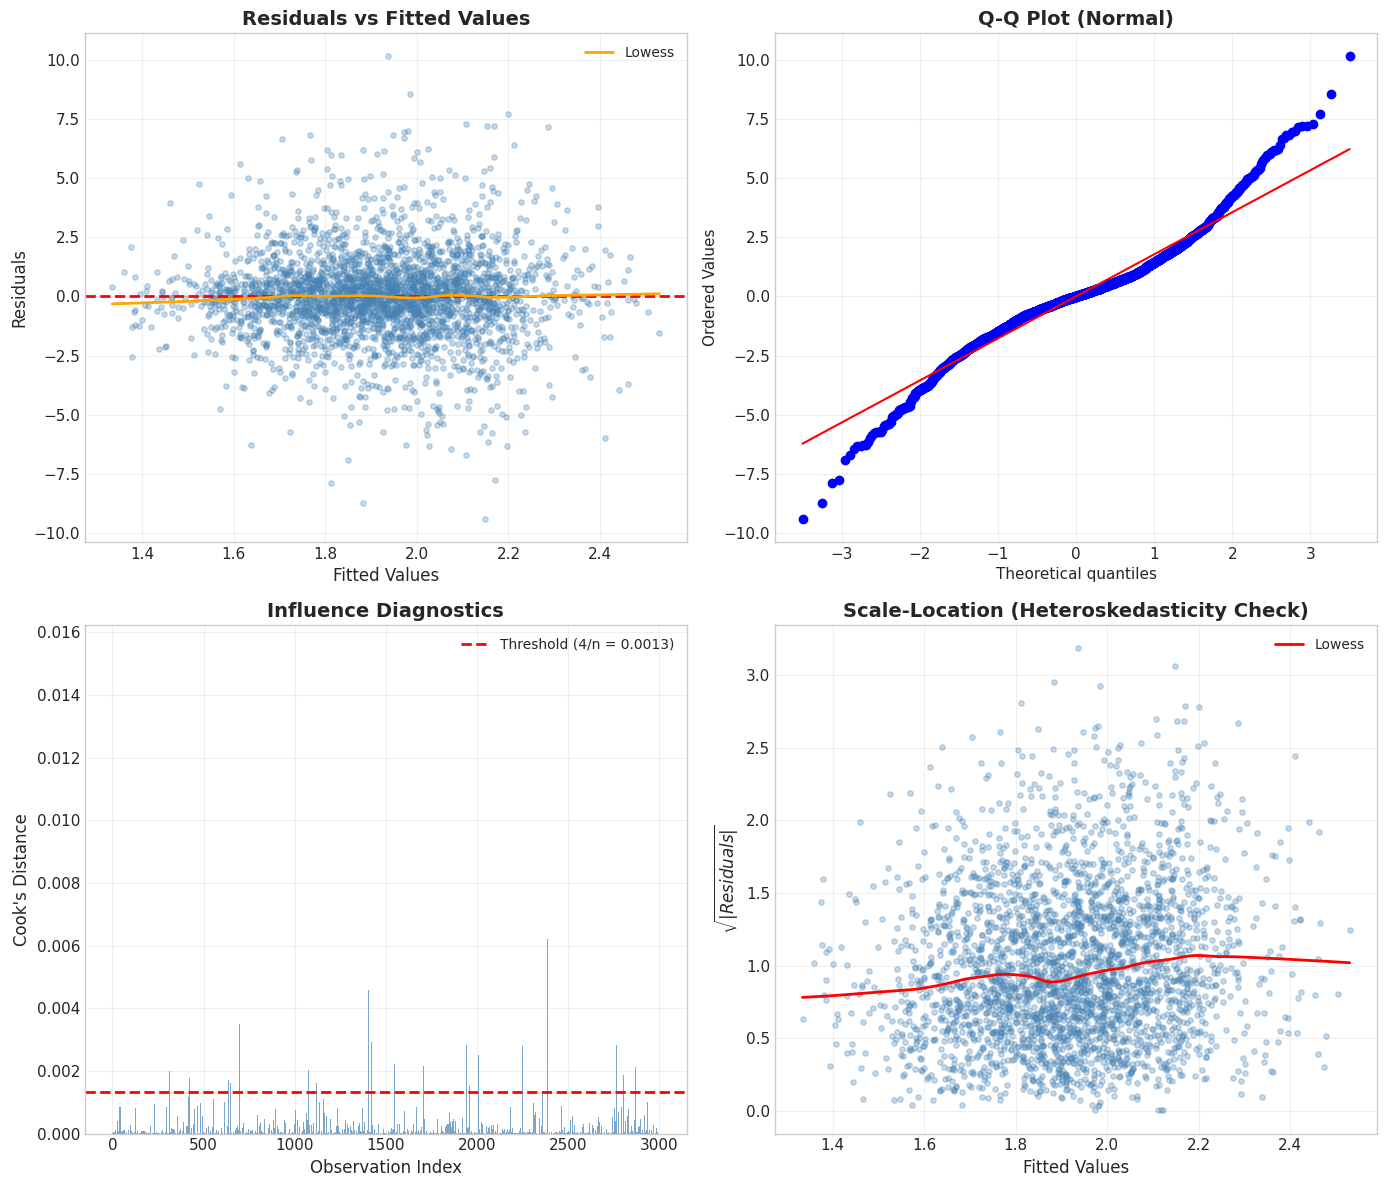

Diagnostic plots saved to outputs/plots/06_diagnostic_plots.png


In [18]:
# Compute quantities for all plots
params_50 = qr_results[0.5].params.ravel()
fitted_50 = X @ params_50
resid_50 = y - fitted_50

# Cook's D (reuse from influence diagnostics)
diag_plots = AdvancedDiagnostics(result_wrapped, verbose=False)
diag_plots.test_influence(tau=0.5)
cooks_d = diag_plots.cooks_d

# 4-panel diagnostic plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(fitted_50, resid_50, alpha=0.3, s=15, color="steelblue")
ax.axhline(0, color="red", linestyle="--", linewidth=2)
# Lowess smooth
try:
    smooth_rv = lowess(resid_50, fitted_50, frac=0.3)
    ax.plot(smooth_rv[:, 0], smooth_rv[:, 1], "orange", linewidth=2, label="Lowess")
    ax.legend(fontsize=10)
except:
    pass
ax.set_xlabel("Fitted Values", fontsize=12)
ax.set_ylabel("Residuals", fontsize=12)
ax.set_title("Residuals vs Fitted Values", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)

# Plot 2: Q-Q plot
ax = axes[0, 1]
stats.probplot(resid_50, dist="norm", plot=ax)
ax.set_title("Q-Q Plot (Normal)", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)

# Plot 3: Cook's Distance
ax = axes[1, 0]
n_obs = len(cooks_d)
# Use bar plot for clarity (stem can be slow with many points)
ax.bar(range(n_obs), cooks_d, width=1.0, alpha=0.7, color="steelblue")
threshold_cook = 4 / n_obs
ax.axhline(
    threshold_cook,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold (4/n = {threshold_cook:.4f})",
)
ax.set_xlabel("Observation Index", fontsize=12)
ax.set_ylabel("Cook's Distance", fontsize=12)
ax.set_title("Influence Diagnostics", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Plot 4: Scale-Location
ax = axes[1, 1]
sqrt_abs_resid = np.sqrt(np.abs(resid_50))
ax.scatter(fitted_50, sqrt_abs_resid, alpha=0.3, s=15, color="steelblue")
try:
    smooth_sl = lowess(sqrt_abs_resid, fitted_50, frac=0.3)
    ax.plot(smooth_sl[:, 0], smooth_sl[:, 1], "r-", linewidth=2, label="Lowess")
    ax.legend(fontsize=10)
except:
    pass
ax.set_xlabel("Fitted Values", fontsize=12)
ax.set_ylabel("$\\sqrt{|Residuals|}$", fontsize=12)
ax.set_title("Scale-Location (Heteroskedasticity Check)", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_diagnostic_plots.png", dpi=300, bbox_inches="tight")
plt.show()

print("Diagnostic plots saved to outputs/plots/06_diagnostic_plots.png")

*Figure: Four-panel diagnostic display for quantile regression at $\tau=0.5$. Top-left: residuals vs fitted values with Lowess smooth—look for systematic patterns. Top-right: Q-Q plot—QR residuals are NOT expected to be normal. Bottom-left: Cook's distance identifying influential observations. Bottom-right: Scale-location plot checking for heteroskedasticity.*

---

## 5. Case Study: Diagnosing a Wage Regression

Let's apply the full diagnostic workflow to our wage regression, identify issues, take corrective action, and verify improvement.

### Step 1: Diagnose the initial model

In [19]:
# Initial model: lwage ~ const + educ + exper + exper^2
print("=" * 60)
print("STEP 1: DIAGNOSE INITIAL MODEL")
print("Model: lwage ~ const + educ + exper + exper_sq")
print("=" * 60)

# Run full diagnostics on the initial model
diag_initial = AdvancedDiagnostics(result_wrapped, verbose=False)
report_initial = diag_initial.run_all_diagnostics(tau=0.5)

# Custom formatted output
print(f"\nHealth Score: {report_initial.health_score:.1%}")
print(f"Health Status: {report_initial.health_status.upper()}")
print()

status_symbols = {"pass": "PASS", "warning": "WARN", "fail": "FAIL"}
for d in report_initial.diagnostics:
    symbol = status_symbols.get(d.status, d.status)
    stat_str = f"{d.statistic:.4f}" if not np.isnan(d.statistic) else "N/A"
    print(f"  [{symbol:>4}] {d.test_name:<30} stat={stat_str}")

# Identify problems
problems = [d for d in report_initial.diagnostics if d.status in ("warning", "fail")]
if problems:
    print(f"\nIssues found ({len(problems)}):")
    for d in problems:
        print(f"  - {d.test_name}: {d.message}")
        if d.recommendation:
            print(f"    Recommendation: {d.recommendation}")
else:
    print("\nNo issues found - model is well specified.")

STEP 1: DIAGNOSE INITIAL MODEL
Model: lwage ~ const + educ + exper + exper_sq

Health Score: 16.7%
Health Status: POOR

  [FAIL] Khmaladze Specification Test   stat=13.7022
  [FAIL] He-Zhu Heteroscedasticity Test stat=68.1201
  [FAIL] Outlier Detection              stat=187.0000
  [FAIL] Influence Diagnostics          stat=169.0000
  [FAIL] Convergence Check              stat=0.1015
  [PASS] Monotonicity Check             stat=0.0000

Issues found (5):
  - Khmaladze Specification Test: Strong evidence of misspecification
    Recommendation: Model is misspecified. Add omitted variables or transform existing ones
  - He-Zhu Heteroscedasticity Test: Strong evidence of heteroscedasticity
    Recommendation: Use location-scale model or weighted QR
  - Outlier Detection: 187 outliers detected (6.2%)
    Recommendation: Too many outliers. Check data quality or use robust methods
  - Influence Diagnostics: 169 highly influential observations
    Recommendation: Model is sensitive to specific o

### Step 2: Take corrective action

Based on the diagnostics above, let's improve the model by adding interaction terms and demographic controls.

In [20]:
# Step 2: Augmented model with additional controls
print("=" * 60)
print("STEP 2: AUGMENTED MODEL")
print("Model: lwage ~ const + educ + exper + exper_sq + female + married + educ*exper")
print("=" * 60)

# Extended design matrix
var_names_aug = ["const", "educ", "exper", "exper_sq", "female", "married", "educ_x_exper"]
X_aug = np.column_stack(
    [
        np.ones(len(data)),
        data["educ"].values,
        data["exper"].values,
        data["exper"].values ** 2,
        data["female"].values,
        data["married"].values,
        data["educ"].values * data["exper"].values,  # interaction
    ]
)

print(f"Original X: {X.shape[1]} variables")
print(f"Augmented X: {X_aug.shape[1]} variables ({var_names_aug})")

# Fit augmented model
qr_results_aug = {}
for tau in tau_list:
    model = PooledQuantile(y, X_aug, entity_id=entity_id, quantiles=tau)
    qr_results_aug[tau] = model.fit(se_type="cluster")

# Wrap for diagnostics
result_aug_wrapped = ResultWrapper(qr_results_aug, X_aug, y)

print("\nAugmented model fitted for all quantiles.")

STEP 2: AUGMENTED MODEL
Model: lwage ~ const + educ + exper + exper_sq + female + married + educ*exper
Original X: 4 variables
Augmented X: 7 variables (['const', 'educ', 'exper', 'exper_sq', 'female', 'married', 'educ_x_exper'])

Augmented model fitted for all quantiles.


In [21]:
# Step 3: Re-diagnose augmented model
print("=" * 60)
print("STEP 3: DIAGNOSE AUGMENTED MODEL")
print("=" * 60)

diag_aug = AdvancedDiagnostics(result_aug_wrapped, verbose=False)
report_aug = diag_aug.run_all_diagnostics(tau=0.5)

print(f"\nHealth Score: {report_aug.health_score:.1%}")
print(f"Health Status: {report_aug.health_status.upper()}")

# Compare initial vs augmented
print("\n" + "-" * 60)
print("COMPARISON: Initial vs Augmented Model")
print("-" * 60)
print(f"{'':<30} {'Initial':<15} {'Augmented':<15}")
print(
    f"{'Health Score':<30} {report_initial.health_score:.1%}{'':<10} {report_aug.health_score:.1%}"
)

for d_init, d_aug in zip(report_initial.diagnostics, report_aug.diagnostics):
    init_str = d_init.status.upper()
    aug_str = d_aug.status.upper()
    change = (
        "  (improved)"
        if (
            (d_init.status == "fail" and d_aug.status in ("pass", "warning"))
            or (d_init.status == "warning" and d_aug.status == "pass")
        )
        else ""
    )
    print(f"{d_init.test_name:<30} {init_str:<15} {aug_str:<15}{change}")

# Pseudo-R2 comparison
pr2_init = pseudo_r_squared(y, X, qr_results[0.5].params.ravel(), 0.5)
pr2_aug = pseudo_r_squared(y, X_aug, qr_results_aug[0.5].params.ravel(), 0.5)
print(f"\n{'Pseudo-R2 (tau=0.5)':<30} {pr2_init:<15.4f} {pr2_aug:<15.4f}")

STEP 3: DIAGNOSE AUGMENTED MODEL



Health Score: 16.7%
Health Status: POOR

------------------------------------------------------------
COMPARISON: Initial vs Augmented Model
------------------------------------------------------------
                               Initial         Augmented      
Health Score                   16.7%           16.7%
Khmaladze Specification Test   FAIL            FAIL           
He-Zhu Heteroscedasticity Test FAIL            FAIL           
Outlier Detection              FAIL            FAIL           
Influence Diagnostics          FAIL            FAIL           
Convergence Check              FAIL            FAIL           
Monotonicity Check             PASS            PASS           

Pseudo-R2 (tau=0.5)            0.0115          0.0154         


---

## 6. Corrective Actions Guide

When diagnostics flag problems, use this decision matrix to guide corrective actions:

| Issue | Recommended Action |
|-------|-------------------|
| **Khmaladze REJECTS** | Add omitted variables, interactions, polynomial terms. Consider nonparametric specifications. |
| **He-Zhu REJECTS** | Use a location-scale model (Notebook 05). Use robust standard errors. |
| **High Outlier %** | Investigate data quality. Consider robust QR at different $\tau$. Winsorize extreme values. |
| **High Influence** | Investigate specific observations for data entry errors. Run sensitivity analysis. |
| **Non-convergence** | Check data scaling. Try different starting values. Reduce tolerance. |
| **Quantile Crossing** | Use monotonicity correction (rearrangement, constrained QR). Use location-scale model. |

> **Key Insight**  
> Heteroskedasticity detected by He-Zhu is not always a "problem"—it's often the phenomenon that QR is designed to study. Only act on it if it indicates misspecification or if you need non-crossing quantile curves.

In [22]:
# Corrective actions demonstration: handling specific issues


def corrective_action_guide(report):
    """Print actionable recommendations based on diagnostic report."""
    print("CORRECTIVE ACTIONS GUIDE")
    print("=" * 60)

    action_map = {
        "Khmaladze Specification Test": {
            "fail": [
                "Add omitted variables (demographics, interactions)",
                "Include polynomial terms (e.g., exper^3)",
                "Consider nonparametric quantile regression",
                "Check for structural breaks in the data",
            ],
            "warning": [
                "Consider adding interaction terms",
                "Run Ramsey RESET-style test for functional form",
            ],
        },
        "He-Zhu Heteroscedasticity Test": {
            "fail": [
                "Use location-scale model (see Notebook 05)",
                "Use cluster-robust standard errors",
                "Consider weighted quantile regression",
            ],
            "warning": [
                "Ensure cluster-robust SEs are being used",
                "Consider location-scale model for non-crossing",
            ],
        },
        "Outlier Detection": {
            "fail": [
                "Investigate data quality for flagged observations",
                "Winsorize extreme values (e.g., at 1st/99th percentile)",
                "Run sensitivity analysis excluding outliers",
            ],
            "warning": [
                "Review most extreme observations for data errors",
            ],
        },
        "Influence Diagnostics": {
            "fail": [
                "Check data entry for influential observations",
                "Run analysis with and without influential obs",
                "Report sensitivity analysis in results",
            ],
            "warning": [
                "Note most influential observations in report",
            ],
        },
        "Convergence Check": {
            "fail": [
                "Standardize/scale covariates before estimation",
                "Try different optimization method (gradient_descent)",
                "Increase maxiter or reduce tolerance",
            ],
            "warning": [
                "Consider tighter convergence tolerance",
            ],
        },
        "Monotonicity Check": {
            "fail": [
                "Apply rearrangement method (Chernozhukov et al. 2010)",
                "Use constrained quantile regression",
                "Use location-scale model (guarantees non-crossing)",
            ],
            "warning": [
                "Minor crossing may be acceptable",
                "Consider rearrangement for prediction purposes",
            ],
        },
    }

    for d in report.diagnostics:
        if d.status in ("warning", "fail"):
            actions = action_map.get(d.test_name, {}).get(d.status, [])
            print(f"\n[{d.status.upper()}] {d.test_name}")
            print(f"  Issue: {d.message}")
            if actions:
                print("  Actions:")
                for action in actions:
                    print(f"    -> {action}")
            elif d.recommendation:
                print(f"  Action: {d.recommendation}")

    passes = sum(1 for d in report.diagnostics if d.status == "pass")
    if passes == len(report.diagnostics):
        print("\nAll tests PASSED - no corrective actions needed.")
    print("\n" + "=" * 60)


corrective_action_guide(report_initial)

CORRECTIVE ACTIONS GUIDE

[FAIL] Khmaladze Specification Test
  Issue: Strong evidence of misspecification
  Actions:
    -> Add omitted variables (demographics, interactions)
    -> Include polynomial terms (e.g., exper^3)
    -> Consider nonparametric quantile regression
    -> Check for structural breaks in the data

[FAIL] He-Zhu Heteroscedasticity Test
  Issue: Strong evidence of heteroscedasticity
  Actions:
    -> Use location-scale model (see Notebook 05)
    -> Use cluster-robust standard errors
    -> Consider weighted quantile regression

[FAIL] Outlier Detection
  Issue: 187 outliers detected (6.2%)
  Actions:
    -> Investigate data quality for flagged observations
    -> Winsorize extreme values (e.g., at 1st/99th percentile)
    -> Run sensitivity analysis excluding outliers

[FAIL] Influence Diagnostics
  Issue: 169 highly influential observations
  Actions:
    -> Check data entry for influential observations
    -> Run analysis with and without influential obs
    -> 

---

## 7. Diagnostics Across Multiple Quantiles

A key advantage of QR diagnostics is that we can check model health at **each quantile separately**. Problems may be quantile-specific: a model that fits well at the median may fail at the tails.

In [23]:
# Run diagnostics at each quantile and compare
print("DIAGNOSTICS ACROSS QUANTILES")
print("=" * 70)

multi_reports = {}
for tau in tau_list:
    diag_tau = AdvancedDiagnostics(result_wrapped, verbose=False)
    multi_reports[tau] = diag_tau.run_all_diagnostics(tau=tau)

# Summary table
print(f"\n{'Quantile':<10}", end="")
test_names = [d.test_name[:20] for d in multi_reports[0.5].diagnostics]
for name in test_names:
    print(f"{name:<22}", end="")
print(f"{'Health':<10}")
print("-" * (10 + 22 * len(test_names) + 10))

for tau in tau_list:
    print(f"{tau:<10.2f}", end="")
    for d in multi_reports[tau].diagnostics:
        print(f"{d.status.upper():<22}", end="")
    print(f"{multi_reports[tau].health_score:.1%}")

print()
print("Are problems consistent or quantile-specific?")

# Check for quantile-specific issues
for test_idx, test_name in enumerate(test_names):
    statuses = [multi_reports[tau].diagnostics[test_idx].status for tau in tau_list]
    if len(set(statuses)) > 1:
        print(f"  {test_name}: VARIES across quantiles ({dict(zip(tau_list, statuses))})")
    else:
        print(f"  {test_name}: Consistent ({statuses[0]})")

DIAGNOSTICS ACROSS QUANTILES



Quantile  Khmaladze Specificat  He-Zhu Heteroscedast  Outlier Detection     Influence Diagnostic  Convergence Check     Monotonicity Check    Health    
--------------------------------------------------------------------------------------------------------------------------------------------------------
0.10      FAIL                  FAIL                  FAIL                  FAIL                  FAIL                  PASS                  16.7%
0.25      FAIL                  FAIL                  FAIL                  FAIL                  FAIL                  PASS                  16.7%
0.50      FAIL                  FAIL                  FAIL                  FAIL                  FAIL                  PASS                  16.7%
0.75      FAIL                  FAIL                  FAIL                  FAIL                  FAIL                  PASS                  16.7%
0.90      FAIL                  FAIL                  FAIL                  FAIL                  FAI

---

## Summary and Key Takeaways

1. **QR needs different diagnostics** than OLS: Pseudo-$R^2$ instead of $R^2$, MAD-based outlier detection instead of standardized residuals, and QR-specific specification tests.

2. **Khmaladze test** checks whether $Q_\tau(Y|X) = X'\beta(\tau)$ is correctly specified. Rejection suggests adding variables, interactions, or nonlinear terms.

3. **He-Zhu test** detects heteroskedasticity. In QR, this is not always a problem—it often motivates the analysis. If non-crossing is needed, consider a location-scale model.

4. **Traffic light system** provides a quick health assessment. Always review individual test results even when the overall score is good.

5. **Diagnostics can be quantile-specific**: Always check at multiple quantiles, not just the median.

6. **Corrective actions** should be guided by the specific diagnostic failure, not applied blindly.

### References

1. Khmaladze, E. V., & Koul, H. L. (2004). Martingale Transforms Goodness-of-Fit Tests in Regression Models. *Annals of Statistics*, 32(3), 995-1034.
2. He, X., & Zhu, L. (2003). A Lack-of-Fit Test for Quantile Regression. *JASA*, 98(464), 1013-1022.
3. Koenker, R., & Machado, J. A. F. (1999). Goodness of Fit and Related Inference Processes for Quantile Regression. *JASA*, 94(448), 1296-1310.

### Next Steps

In **Notebook 07**, we explore **Bootstrap Inference** for quantile regression, providing more reliable standard errors and confidence intervals.

---

## Exercises

### Exercise 1: Run Full Diagnostics on Pooled QR Model (Easy)

**Task**: Using the augmented model (with `female`, `married`, and `educ*exper` interaction), run the full diagnostic suite at $\tau=0.5$. Interpret each test result in plain language.

**Steps**:
1. Create a `ResultWrapper` for the augmented model results
2. Run `AdvancedDiagnostics.run_all_diagnostics(tau=0.5)`
3. Print the health score and interpret each test

In [24]:
# Exercise 1: Run full diagnostics on augmented model

# TODO: Create ResultWrapper for augmented model
# TODO: Run AdvancedDiagnostics.run_all_diagnostics(tau=0.5)
# TODO: Print health score and interpret each test


### Exercise 2: Custom Outlier Detection with IQR Method (Easy)

**Task**: Implement an outlier detection method using the IQR (interquartile range) of residuals instead of MAD. Compare the results with the MAD-based method.

**IQR method**:
- Compute $Q_1$ and $Q_3$ of residuals
- $\text{IQR} = Q_3 - Q_1$
- Outlier if $u_i < Q_1 - 1.5 \times \text{IQR}$ or $u_i > Q_3 + 1.5 \times \text{IQR}$

In [25]:
# Exercise 2: IQR-based outlier detection

# TODO: Compute residuals for tau=0.5
# TODO: Implement IQR-based outlier detection
# TODO: Compare with MAD-based method (number, percentage, overlap)


### Exercise 3: Custom Health Score Function (Medium)

**Task**: Create your own health score function that:
1. Takes a list of diagnostic results
2. Assigns custom weights to each test (e.g., specification test is more important than outlier count)
3. Returns a weighted health score

**Suggested weights**:
- Specification test: weight = 3
- Heteroskedasticity: weight = 2
- Outlier detection: weight = 1
- Influence: weight = 1
- Convergence: weight = 3

In [26]:
# Exercise 3: Custom weighted health score

# TODO: Define custom weights for each test
# TODO: Implement weighted_health_score(diagnostics, weights) function
# TODO: Compare with default (equal-weight) health score


### Exercise 4: Detect Misspecification (Medium)

**Task**: Simulate data with a known misspecification:
1. True DGP: $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon$
2. Estimate a **linear-only** model: $Y = \beta_0 + \beta_1 X + u$ (omitting $X^2$)
3. Run the Khmaladze specification test
4. Show that it detects the misspecification
5. Then add $X^2$ to the model and re-test

In [27]:
# Exercise 4: Simulate misspecified model

# TODO: Generate data with quadratic DGP
# TODO: Fit linear-only QR model
# TODO: Run Khmaladze test (should reject)
# TODO: Fit correct model with X^2
# TODO: Run Khmaladze test again (should not reject)


### Exercise 5: Compare Diagnostics Across Quantiles (Hard)

**Task**: Run the full diagnostic suite at $\tau \in \{0.1, 0.25, 0.5, 0.75, 0.9\}$. Create a summary table and determine whether problems are consistent or quantile-specific.

**Bonus**: Create a heatmap visualization of the diagnostic statuses.

In [28]:
# Exercise 5: Diagnostics across quantiles

# TODO: Run diagnostics for each tau in [0.1, 0.25, 0.5, 0.75, 0.9]
# TODO: Create summary table (tau x test_name)
# TODO: Identify quantile-specific problems
# TODO: (Bonus) Create heatmap of pass/warning/fail


### Exercise 6: Full Estimate-Diagnose-Fix-Rediagnose Workflow (Hard)

**Task**: Implement a complete diagnostic workflow:
1. Estimate a simple wage model
2. Run diagnostics and identify problems
3. Fix the model based on diagnostic recommendations
4. Re-diagnose to confirm improvement
5. Document the changes and their impact

**Deliverable**: A function that automates this loop and returns a comparison table.

In [29]:
# Exercise 6: Full diagnostic workflow

# TODO: Define estimate_and_diagnose(y, X, entity_id, tau_list, label) function
# TODO: Run on initial simple model
# TODO: Based on results, modify X (add variables, interactions)
# TODO: Re-run and compare
# TODO: Document findings
